## Personal Notebook, Naive Bayes, Lotta Kauppinen

##### Using the cleaned_100k.csv and the same skeleton as in the assignment notebook.

### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from imblearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.preprocessing import PolynomialFeatures
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.naive_bayes import GaussianNB

### Reading the CSV and split 60/20/20

In [2]:
df = pd.read_csv("cleaned_100k.csv", low_memory=False)

y = df["Attack Type"]
X = df.drop("Attack Type", axis=1)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25, random_state=42, stratify=y_train_val)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (60000, 52) Val: (20000, 52) Test: (20000, 52)


### Shared skeleton

In [3]:
# Agreed 10-feature list
FEATURES = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Length of Fwd Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Mean",
    "Packet Length Mean",
    "Packet Length Std",
    "Average Packet Size",
]
missing = [f for f in FEATURES if f not in X_train.columns]
assert not missing, f"These features are not in the data: {missing}"

X_train_sel = X_train[FEATURES]
X_val_sel   = X_val[FEATURES]
X_test_sel  = X_test[FEATURES]

CV_FOLDS = 3
SCORING  = "f1_macro"
N_JOBS   = -1

def run_experiment(clf, param_grid, label, use_smote=True, use_pca=True, use_scaler=True, use_lda=False, use_poly=False):

    steps = []

    # 1. scaling
    if use_scaler:
        steps.append(("scaler", StandardScaler()))

    if use_poly:
        steps.append(("poly", PolynomialFeatures(degree=2))) # 29.4. added for polynomial features testing

    # 2. SMOTE (only training data)
    if use_smote:
        steps.append(("smote", SMOTE(random_state=42)))
    # 3.1 Use LDA 
    if use_lda:
        steps.append(("lda", LDA()))

    # 3.2 OR, use PCA (valinnainen)
    if use_pca:
        steps.append(("pca", PCA()))

    # 4. model
    steps.append(("clf", clf))

    pipe = Pipeline(steps)

    grid = GridSearchCV(
        pipe,
        param_grid=param_grid,
        cv=CV_FOLDS,
        scoring=SCORING,
        n_jobs=N_JOBS,
        verbose=1
    )

    grid.fit(X_train_sel, y_train)

    y_val_pred = grid.predict(X_val_sel)
    y_test_pred = grid.predict(X_test_sel)

    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average="macro")

    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred, average="macro")

    # confusion matrix
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_test_pred, ax=ax, xticks_rotation=45, colorbar=False
    )
    ax.set_title(f"{label} — Test Confusion Matrix")
    plt.tight_layout()
    plt.show()

    print(f"\n=== {label} ===")
    print("Best params:", grid.best_params_)
    print(f"Validation acc: {val_acc:.4f}, f1: {val_f1:.4f}")
    print(f"Test acc: {test_acc:.4f}, f1: {test_f1:.4f}")
    print(classification_report(y_test, y_test_pred, digits=3))

    return {
        "label": label,
        "grid": grid,
        "best_params": grid.best_params_,
        "val_acc": val_acc,
        "val_f1_macro": val_f1,
        "test_acc": test_acc,
        "test_f1_macro": test_f1,
        "smote": use_smote,
        "pca": use_pca
    }

all_results = []

### Naive Bayes: Baseline, Scaling, SMOTE, PCA, LDA and Polynomial Features

Fitting 3 folds for each of 3 candidates, totalling 9 fits


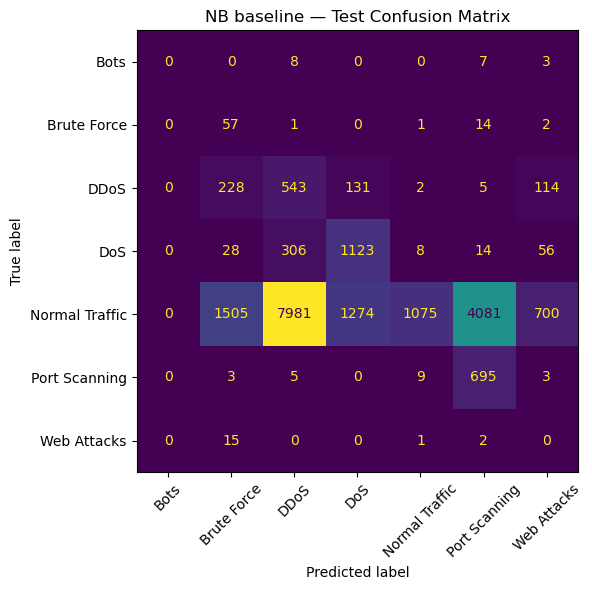


=== NB baseline ===
Best params: {'clf__var_smoothing': 1e-08}
Validation acc: 0.1744, f1: 0.1570
Test acc: 0.1746, f1: 0.1564
                precision    recall  f1-score   support

          Bots      0.000     0.000     0.000        18
   Brute Force      0.031     0.760     0.060        75
          DDoS      0.061     0.531     0.110      1023
           DoS      0.444     0.732     0.553      1535
Normal Traffic      0.981     0.065     0.121     16616
 Port Scanning      0.144     0.972     0.251       715
   Web Attacks      0.000     0.000     0.000        18

      accuracy                          0.175     20000
     macro avg      0.237     0.437     0.156     20000
  weighted avg      0.857     0.175     0.158     20000

Fitting 3 folds for each of 3 candidates, totalling 9 fits


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


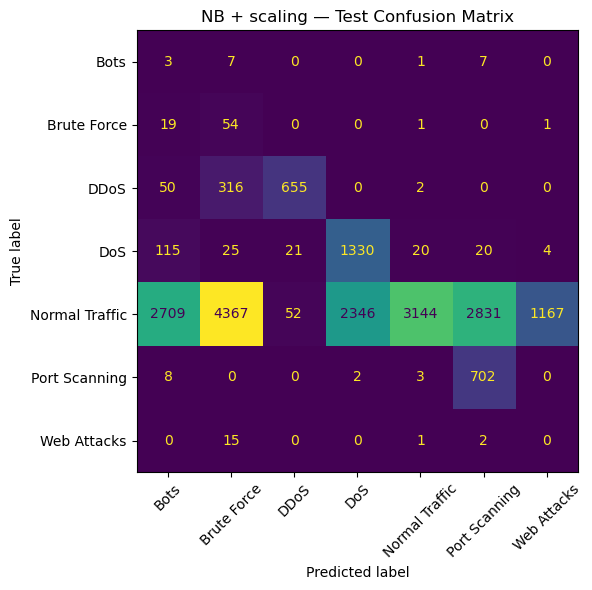


=== NB + scaling ===
Best params: {'clf__var_smoothing': 1e-08}
Validation acc: 0.2936, f1: 0.2778
Test acc: 0.2944, f1: 0.2755
                precision    recall  f1-score   support

          Bots      0.001     0.167     0.002        18
   Brute Force      0.011     0.720     0.022        75
          DDoS      0.900     0.640     0.748      1023
           DoS      0.362     0.866     0.510      1535
Normal Traffic      0.991     0.189     0.318     16616
 Port Scanning      0.197     0.982     0.328       715
   Web Attacks      0.000     0.000     0.000        18

      accuracy                          0.294     20000
     macro avg      0.352     0.509     0.276     20000
  weighted avg      0.904     0.294     0.353     20000

Fitting 3 folds for each of 3 candidates, totalling 9 fits


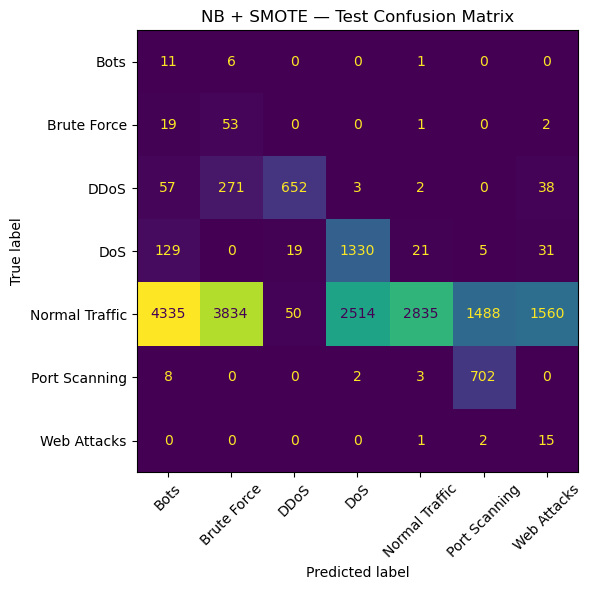


=== NB + SMOTE ===
Best params: {'clf__var_smoothing': 1e-09}
Validation acc: 0.2805, f1: 0.2962
Test acc: 0.2799, f1: 0.2947
                precision    recall  f1-score   support

          Bots      0.002     0.611     0.005        18
   Brute Force      0.013     0.707     0.025        75
          DDoS      0.904     0.637     0.748      1023
           DoS      0.346     0.866     0.494      1535
Normal Traffic      0.990     0.171     0.291     16616
 Port Scanning      0.320     0.982     0.482       715
   Web Attacks      0.009     0.833     0.018        18

      accuracy                          0.280     20000
     macro avg      0.369     0.687     0.295     20000
  weighted avg      0.907     0.280     0.335     20000

Fitting 3 folds for each of 6 candidates, totalling 18 fits


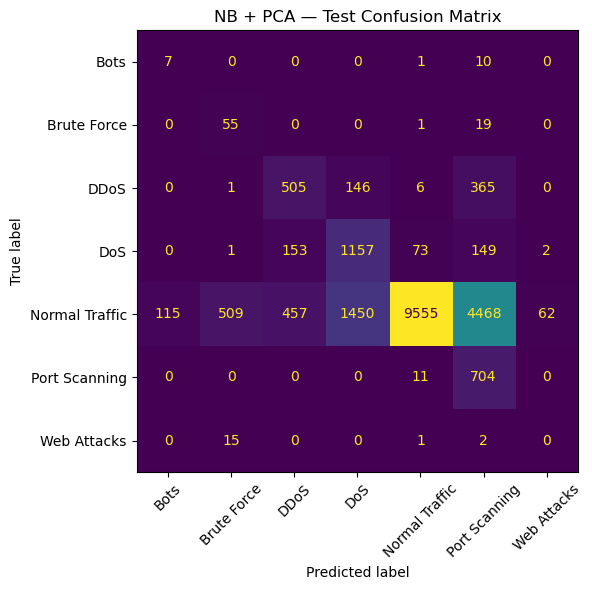


=== NB + PCA ===
Best params: {'clf__var_smoothing': 1e-08, 'pca__n_components': 10}
Validation acc: 0.6016, f1: 0.3243
Test acc: 0.5991, f1: 0.3180
                precision    recall  f1-score   support

          Bots      0.057     0.389     0.100        18
   Brute Force      0.095     0.733     0.168        75
          DDoS      0.453     0.494     0.472      1023
           DoS      0.420     0.754     0.540      1535
Normal Traffic      0.990     0.575     0.728     16616
 Port Scanning      0.123     0.985     0.219       715
   Web Attacks      0.000     0.000     0.000        18

      accuracy                          0.599     20000
     macro avg      0.306     0.561     0.318     20000
  weighted avg      0.883     0.599     0.679     20000

Fitting 3 folds for each of 2 candidates, totalling 6 fits


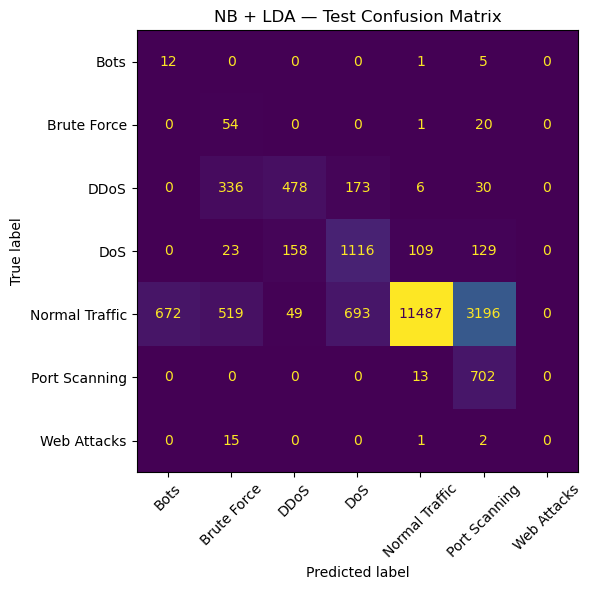


=== NB + LDA ===
Best params: {'clf__var_smoothing': 1e-09}
Validation acc: 0.6955, f1: 0.3547
Test acc: 0.6925, f1: 0.3486
                precision    recall  f1-score   support

          Bots      0.018     0.667     0.034        18
   Brute Force      0.057     0.720     0.106        75
          DDoS      0.698     0.467     0.560      1023
           DoS      0.563     0.727     0.635      1535
Normal Traffic      0.989     0.691     0.814     16616
 Port Scanning      0.172     0.982     0.293       715
   Web Attacks      0.000     0.000     0.000        18

      accuracy                          0.692     20000
     macro avg      0.357     0.608     0.349     20000
  weighted avg      0.907     0.692     0.764     20000

Fitting 3 folds for each of 3 candidates, totalling 9 fits


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


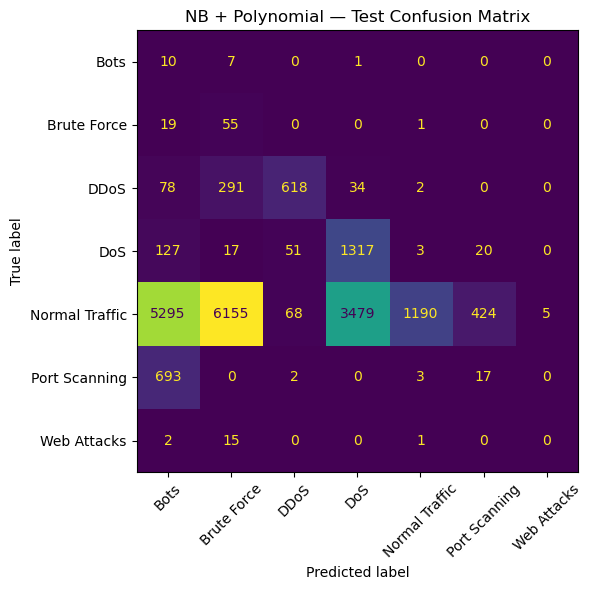


=== NB + Polynomial ===
Best params: {'clf__var_smoothing': 1e-09}
Validation acc: 0.1600, f1: 0.1897
Test acc: 0.1603, f1: 0.1854
                precision    recall  f1-score   support

          Bots      0.002     0.556     0.003        18
   Brute Force      0.008     0.733     0.017        75
          DDoS      0.836     0.604     0.701      1023
           DoS      0.273     0.858     0.414      1535
Normal Traffic      0.992     0.072     0.134     16616
 Port Scanning      0.037     0.024     0.029       715
   Web Attacks      0.000     0.000     0.000        18

      accuracy                          0.160     20000
     macro avg      0.307     0.407     0.185     20000
  weighted avg      0.889     0.160     0.180     20000



In [5]:
nb_param_grid = {
    "clf__var_smoothing": [1e-9, 1e-8, 1e-7]
}

# 1. Baseline
all_results.append(run_experiment(
    GaussianNB(),
    nb_param_grid,
    label="NB baseline",
    use_smote=False,
    use_pca=False,
    use_scaler=False
))

# 2. Scaling
all_results.append(run_experiment(
    GaussianNB(),
    nb_param_grid,
    label="NB + scaling",
    use_smote=False,
    use_pca=False,
    use_scaler=True
))

# 3. SMOTE
all_results.append(run_experiment(
    GaussianNB(),
    nb_param_grid,
    label="NB + SMOTE",
    use_smote=True,
    use_pca=False,
    use_scaler=True
))

# 4. PCA
all_results.append(run_experiment(
    GaussianNB(),
    {
        "clf__var_smoothing": [1e-9, 1e-8],
        "pca__n_components": [5, 8, 10]
    },
    label="NB + PCA",
    use_smote=False,
    use_pca=True,
    use_scaler=True
))

# 5. LDA
all_results.append(run_experiment(
    GaussianNB(),
    {
        "clf__var_smoothing": [1e-9, 1e-8]
    },
    label="NB + LDA",
    use_smote=False,
    use_pca=False,
    use_scaler=True,
    use_lda=True
))

# 6. Polynomial Features
all_results.append(run_experiment(
    GaussianNB(),
    nb_param_grid,
    label="NB + Polynomial",
    use_smote=False,
    use_pca=False,
    use_scaler=True,
    use_poly=True
))

Fitting 3 folds for each of 2 candidates, totalling 6 fits


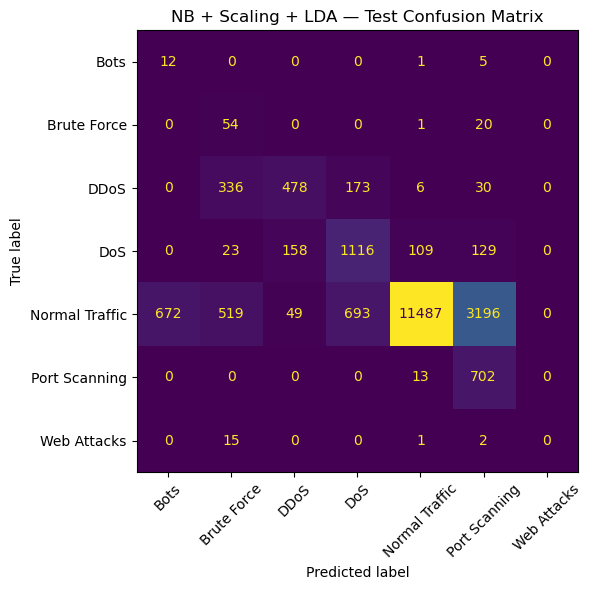


=== NB + Scaling + LDA ===
Best params: {'clf__var_smoothing': 1e-09}
Validation acc: 0.6955, f1: 0.3547
Test acc: 0.6925, f1: 0.3486
                precision    recall  f1-score   support

          Bots      0.018     0.667     0.034        18
   Brute Force      0.057     0.720     0.106        75
          DDoS      0.698     0.467     0.560      1023
           DoS      0.563     0.727     0.635      1535
Normal Traffic      0.989     0.691     0.814     16616
 Port Scanning      0.172     0.982     0.293       715
   Web Attacks      0.000     0.000     0.000        18

      accuracy                          0.692     20000
     macro avg      0.357     0.608     0.349     20000
  weighted avg      0.907     0.692     0.764     20000

Fitting 3 folds for each of 2 candidates, totalling 6 fits


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


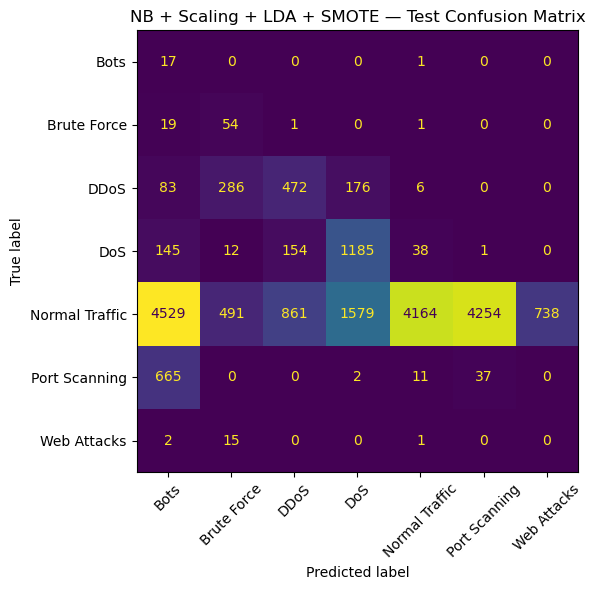


=== NB + Scaling + LDA + SMOTE ===
Best params: {'clf__var_smoothing': 1e-09}
Validation acc: 0.2966, f1: 0.2096
Test acc: 0.2964, f1: 0.2060
                precision    recall  f1-score   support

          Bots      0.003     0.944     0.006        18
   Brute Force      0.063     0.720     0.116        75
          DDoS      0.317     0.461     0.376      1023
           DoS      0.403     0.772     0.529      1535
Normal Traffic      0.986     0.251     0.400     16616
 Port Scanning      0.009     0.052     0.015       715
   Web Attacks      0.000     0.000     0.000        18

      accuracy                          0.296     20000
     macro avg      0.254     0.457     0.206     20000
  weighted avg      0.867     0.296     0.393     20000

Fitting 3 folds for each of 6 candidates, totalling 18 fits


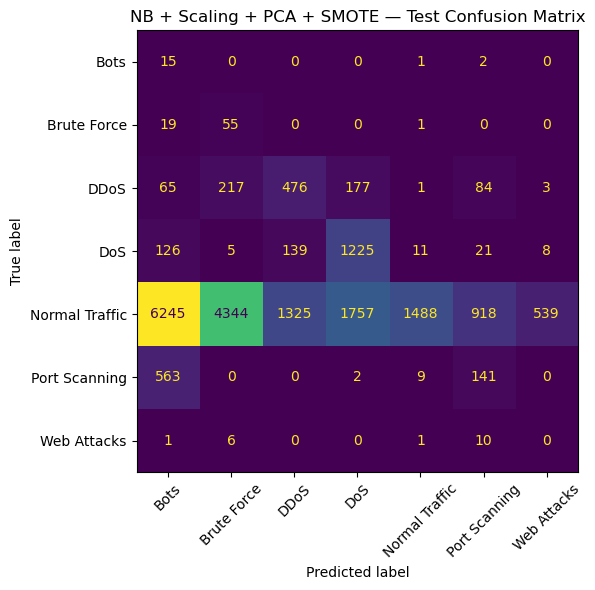


=== NB + Scaling + PCA + SMOTE ===
Best params: {'clf__var_smoothing': 1e-09, 'pca__n_components': 5}
Validation acc: 0.1696, f1: 0.1692
Test acc: 0.1700, f1: 0.1691
                precision    recall  f1-score   support

          Bots      0.002     0.833     0.004        18
   Brute Force      0.012     0.733     0.023        75
          DDoS      0.245     0.465     0.321      1023
           DoS      0.388     0.798     0.522      1535
Normal Traffic      0.984     0.090     0.164     16616
 Port Scanning      0.120     0.197     0.149       715
   Web Attacks      0.000     0.000     0.000        18

      accuracy                          0.170     20000
     macro avg      0.250     0.445     0.169     20000
  weighted avg      0.864     0.170     0.198     20000



In [6]:
nb_param_grid = {
    "clf__var_smoothing": [1e-9, 1e-8]
}

# 1. Scaling + LDA
all_results.append(run_experiment(
    GaussianNB(),
    nb_param_grid,
    label="NB + Scaling + LDA",
    use_scaler=True,
    use_lda=True,
    use_pca=False,
    use_smote=False
))

# 2. Scaling + LDA + SMOTE
all_results.append(run_experiment(
    GaussianNB(),
    nb_param_grid,
    label="NB + Scaling + LDA + SMOTE",
    use_scaler=True,
    use_lda=True,
    use_pca=False,
    use_smote=True
))

# 3. Scaling + PCA + SMOTE
all_results.append(run_experiment(
    GaussianNB(),
    {
        "clf__var_smoothing": [1e-9, 1e-8],
        "pca__n_components": [5, 8, 10]
    },
    label="NB + Scaling + PCA + SMOTE",
    use_scaler=True,
    use_lda=False,
    use_pca=True,
    use_smote=True
))